In [1]:
import argparse
import csv
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'

In [33]:
df1 = pd.read_csv('train-Wu_2021_test-Qian_2020.csv').fillna(0)
df1 = df1[['hk', 'hk_pr', 'hk_pr_std', 'hvg', 'hvg_pr', 'hvg_pr_std', 'nhvg', 'nhvg_pr', 'nhvg_pr_std', 'uc', 'uc_pr', 'uc_pr_std']]
df1

,hk,hk_pr,hk_pr_std,hvg,hvg_pr,hvg_pr_std,nhvg,nhvg_pr,nhvg_pr_std,uc,uc_pr,uc_pr_std
0,2,0.18943,0.02484,1,0.20843,0.04370,18,0.27847,0.03949,0,0.00000,0.00000
1,4,0.22187,0.02654,2,0.22253,0.06192,37,0.35884,0.06454,0,0.00000,0.00000
2,6,0.21434,0.01653,3,0.25927,0.05373,56,0.44152,0.05379,0,0.00000,0.00000
3,8,0.25327,0.05266,4,0.31738,0.10570,75,0.51670,0.05276,0,0.00000,0.00000
4,10,0.27410,0.05016,5,0.37448,0.06932,94,0.56604,0.03743,0,0.00000,0.00000
5,12,0.25011,0.03479,6,0.41748,0.07279,113,0.62749,0.05566,0,0.00000,0.00000
6,14,0.27568,0.05878,7,0.43422,0.08211,132,0.60213,0.04121,0,0.00000,0.00000
7,16,0.28936,0.05124,8,0.44756,0.09770,151,0.64750,0.03994,0,0.00000,0.00000
8,18,0.32233,0.06440,9,0.48503,0.08528,170,0.66546,0.06110,1,0.25802,0.03445
9,20,0.29973,0.05859,10,0.47946,0.10292,189,0.68898,0.05351,1,0.25147,0.03217


In [34]:
df2 = pd.read_csv('train-Qian_2020_test-Wu_2021.csv').fillna(0)
df2 = df2[['hk', 'hk_pr', 'hk_pr_std', 'hvg', 'hvg_pr', 'hvg_pr_std', 'nhvg', 'nhvg_pr', 'nhvg_pr_std', 'uc', 'uc_pr', 'uc_pr_std']]
df2

,hk,hk_pr,hk_pr_std,hvg,hvg_pr,hvg_pr_std,nhvg,nhvg_pr,nhvg_pr_std,uc,uc_pr,uc_pr_std
0,2,0.18430,0.01862,1,0.18205,0.03248,18,0.26008,0.02687,0,0.00000,0.00000
1,4,0.21234,0.02334,2,0.21231,0.04258,37,0.30607,0.05021,0,0.00000,0.00000
2,6,0.20865,0.01484,3,0.22542,0.05246,56,0.35002,0.04620,0,0.00000,0.00000
3,8,0.23869,0.04282,4,0.24014,0.05423,75,0.42378,0.05619,0,0.00000,0.00000
4,10,0.25441,0.04476,5,0.28673,0.06065,94,0.45213,0.04893,0,0.00000,0.00000
5,12,0.23535,0.02554,6,0.31910,0.08878,113,0.50655,0.04966,0,0.00000,0.00000
6,14,0.25253,0.04341,7,0.34404,0.06414,132,0.52368,0.04969,0,0.00000,0.00000
7,16,0.25747,0.03907,8,0.34978,0.07157,151,0.55115,0.06690,1,0.21941,0.03935
8,18,0.28147,0.05111,9,0.37194,0.08163,170,0.55170,0.03894,1,0.23024,0.02908
9,20,0.26351,0.03759,10,0.40096,0.08466,189,0.58844,0.03790,1,0.21562,0.03554


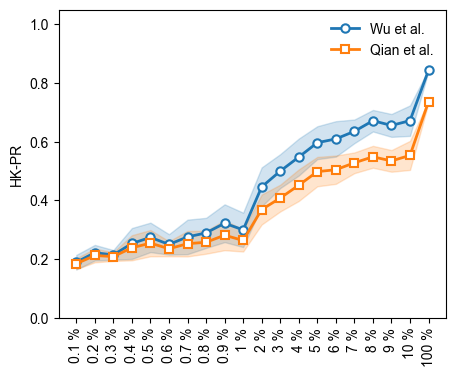

In [45]:
fig, ax1 = plt.subplots(figsize=(5, 4))

# Main curves
ax1.plot(
    df1.index,
    df1['hk_pr'],
    label='Wu et al.',
    color='tab:blue',
    marker='o',
    markerfacecolor='white',
    markeredgewidth=1.5,
    linewidth=2
)

ax1.fill_between(
    df1.index,
    df1['hk_pr'] - df1['hk_pr_std'],
    df1['hk_pr'] + df1['hk_pr_std'],
    color='tab:blue',
    alpha=0.2
)

ax1.plot(
    df2.index,
    df2['hk_pr'],
    label='Qian et al.',
    color='tab:orange',
    marker='s',
    markerfacecolor='white',
    markeredgewidth=1.5,
    linewidth=2
)

ax1.fill_between(
    df2.index,
    df2['hk_pr'] - df2['hk_pr_std'],
    df2['hk_pr'] + df2['hk_pr_std'],
    color='tab:orange',
    alpha=0.2
)

ax1.set_ylim(0, 1.05)
ax1.set_ylabel("HK-PR")
ax1.legend(frameon=False)

tick_idx = np.arange(len(diff))
ax1.set_xticks(tick_idx)
ax1.set_xticklabels(
    ['0.1 %','0.2 %','0.3 %','0.4 %','0.5 %',
     '0.6 %','0.7 %','0.8 %','0.9 %','1 %',
     '2 %','3 %','4 %','5 %','6 %',
     '7 %','8 %','9 %','10 %','100 %'],
    rotation=90
)
plt.savefig('Wu_Qian_hk_diff.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

C:\Users\shrey\AppData\Local\Temp\ipykernel_10000\2898646988.py:65: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax2.scatter(


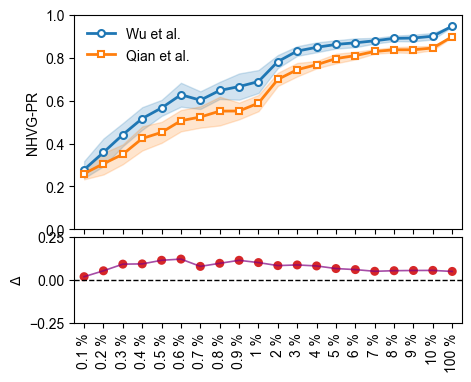

In [39]:
diff = df1['nhvg_pr'] - df2['nhvg_pr']

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(5, 4),
    sharex=True,
    gridspec_kw={'height_ratios': [10, 4], 'hspace': 0.05}
)

# ======================
# Line plots
# ======================
ax1.plot(
    df1.index,
    df1['nhvg_pr'],
    label='Wu et al.',
    color='tab:blue',
    marker='o',
    markersize=5,
    markerfacecolor='white',
    markeredgewidth=1.5,
    linewidth=2
)

ax1.fill_between(
    df1.index,
    df1['nhvg_pr'] - df1['nhvg_pr_std'],
    df1['nhvg_pr'] + df1['nhvg_pr_std'],
    color='tab:blue',
    alpha=0.2
)

ax1.plot(
    df2.index,
    df2['nhvg_pr'],
    label='Qian et al.',
    color='tab:orange',
    marker='s',
    markersize=5,
    markerfacecolor='white',
    markeredgewidth=1.5,
    linewidth=2
)

ax1.fill_between(
    df2.index,
    df2['nhvg_pr'] - df2['nhvg_pr_std'],
    df2['nhvg_pr'] + df2['nhvg_pr_std'],
    color='tab:orange',
    alpha=0.2
)

# y-axis from 0 to 1
ax1.set_ylim(0, 1)
ax1.set_ylabel("NHVG-PR")
ax1.legend(frameon=False)

# ======================
# Difference scatter plot
# ======================
tick_idx = np.arange(len(diff))

colors = np.where(diff >= 0, 'tab:red', 'tab:blue')

ax2.scatter(
    tick_idx,
    diff.values,
    c=colors,
    s=25,
    marker='o',
    facecolors='white',
    linewidths=1.5
)

# Optional: connect the points
ax2.plot(
    tick_idx,
    diff.values,
    color='purple',
    linewidth=1.2,
    alpha=0.7,
    zorder=2
)

# Horizontal zero reference line
ax2.axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1
)

# Limits
ax2.set_ylim(-0.25, 0.25)
ax2.set_yticks([-0.25, 0, 0.25])
ax2.set_ylabel(r'$\Delta$')

# x-axis
ax2.set_xlim(-0.5, len(diff)-0.5)
ax2.set_xticks(tick_idx)
ax2.set_xticklabels(
    [
        '0.1 %','0.2 %','0.3 %','0.4 %','0.5 %',
        '0.6 %','0.7 %','0.8 %','0.9 %','1 %',
        '2 %','3 %','4 %','5 %','6 %',
        '7 %','8 %','9 %','10 %','100 %'
    ],
    rotation=90
)

# plt.tight_layout()
# plt.savefig('Wu_Qian_nhvg_diff.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

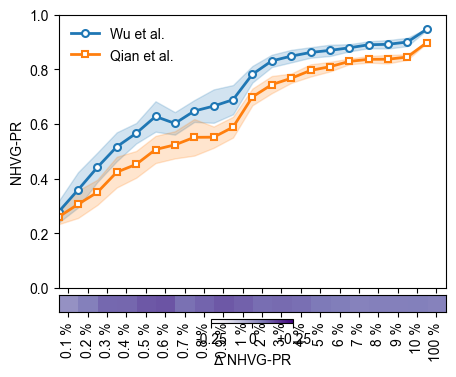

In [26]:
diff = df1['nhvg_pr'] - df2['nhvg_pr']

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(5, 4),
    sharex=True,
    gridspec_kw={'height_ratios': [10, 1], 'hspace': 0.05}
)

# ======================
# Line plots
# ======================
ax1.plot(
    df1.index,
    df1['nhvg_pr'],
    label='Wu et al.',
    color='tab:blue',
    marker='o',
    markersize=5,
    markerfacecolor='white',
    markeredgewidth=1.5,
    linewidth=2
)

ax1.fill_between(
    df1.index,
    df1['nhvg_pr'] - df1['nhvg_pr_std'],
    df1['nhvg_pr'] + df1['nhvg_pr_std'],
    color='tab:blue',
    alpha=0.2
)

ax1.plot(
    df2.index,
    df2['nhvg_pr'],
    label='Qian et al.',
    color='tab:orange',
    marker='s',
    markersize=5,
    markerfacecolor='white',
    markeredgewidth=1.5,
    linewidth=2
)

ax1.fill_between(
    df2.index,
    df2['nhvg_pr'] - df2['nhvg_pr_std'],
    df2['nhvg_pr'] + df2['nhvg_pr_std'],
    color='tab:orange',
    alpha=0.2
)

# y-axis from 0 to 1
ax1.set_ylim(0, 1)
ax1.set_ylabel("NHVG-PR")
ax1.legend(frameon=False)

# ======================
# Heatmap
# ======================
im = ax2.imshow(
    diff.values[np.newaxis, :],
    aspect='auto',
    cmap='Purples',      # diverging colormap
    interpolation='nearest',
    extent=[0, len(diff), 0, 1],
    vmin=-0.25,
    vmax=0.25
)

ax2.set_yticks([])

tick_idx = np.arange(len(diff))
ax2.set_xticks(tick_idx + 0.5)
ax2.set_xticklabels(
    [
        '0.1 %','0.2 %','0.3 %','0.4 %','0.5 %',
        '0.6 %','0.7 %','0.8 %','0.9 %','1 %',
        '2 %','3 %','4 %','5 %','6 %',
        '7 %','8 %','9 %','10 %','100 %'
    ],
    rotation=90
)

# ======================
# Colorbar
# ======================
cbar = plt.colorbar(
    im,
    ax=ax2,
    orientation='horizontal',
    pad=0.25
)

cbar.set_ticks([-0.25, 0, 0.25])
cbar.set_ticklabels(['-0.25', '0', '+0.25'])
cbar.set_label(r'$\Delta$ NHVG-PR')

# plt.tight_layout()
plt.savefig('Wu_Qian_nhvg_diff.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

In [64]:
df1 = pd.read_csv('Sergio_5_10.csv')
# df1 = df1[['high_pr', 'high_pr_std', 'low_pr', 'low_pr_std']]
df1 = df1[['high_auc', 'high_auc_std', 'low_auc', 'low_auc_std']]
df1 = df1.loc[[13, 18, 19]]
df1.index = ['5 %', '10 %', '100 %']
df1

,high_auc,high_auc_std,low_auc,low_auc_std
5 %,0.90135,0.04213,0.65741,0.02976
10 %,0.96834,0.01195,0.74165,0.03071
100 %,1.00000,0.00000,0.97390,0.00430


In [65]:
df2 = pd.read_csv('Sergio_20_30.csv')
# df2 = df2[['high_pr', 'high_pr_std', 'low_pr', 'low_pr_std']]
df2 = df2[['high_auc', 'high_auc_std', 'low_auc', 'low_auc_std']]
df2 = df2.loc[[13, 18, 19]]
df2.index = ['5 %', '10 %', '100 %']
df2

,high_auc,high_auc_std,low_auc,low_auc_std
5 %,0.85054,0.06319,0.60485,0.03044
10 %,0.93502,0.02996,0.65341,0.02818
100 %,1.00000,0.00000,0.90740,0.00820


In [66]:
df3 = pd.read_csv('Sergio_50_60.csv')
# df3 = df3[['high_pr', 'high_pr_std', 'low_pr', 'low_pr_std']]
df3 = df3[['high_auc', 'high_auc_std', 'low_auc', 'low_auc_std']]
df3 = df3.loc[[13, 18, 19]]
df3.index = ['5 %', '10 %', '100 %']
df3

,high_auc,high_auc_std,low_auc,low_auc_std
5 %,0.77576,0.07454,0.57008,0.01932
10 %,0.86539,0.05010,0.60920,0.01872
100 %,0.99970,0.00030,0.81720,0.01310


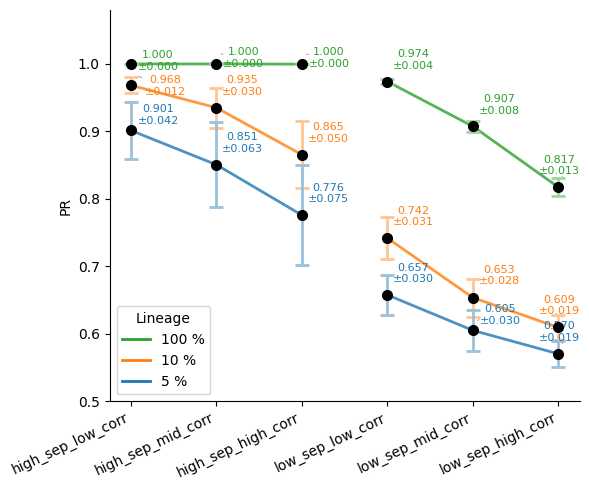

In [70]:
import matplotlib.colors as mcolors
dfs = [df1, df2, df3]

# -----------------------------
# Utility to lighten colors
# -----------------------------
def lighten(color, amount=0.45):
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1 - c) * amount)

# Colors for 13,18,19
colors = {
    '5 %': "#1f77b4",
    '10 %': "#ff7f0e",
    '100 %': "#2ca02c"
}

# Desired plotting order
lineages = ["100 %","10 %","5 %"]

# x-axis labels
xlabels = [
    "high_sep_low_corr","high_sep_mid_corr","high_sep_high_corr",
    "low_sep_low_corr","low_sep_mid_corr","low_sep_high_corr"
]

fig, ax = plt.subplots(figsize=(6,5))

x = np.arange(len(xlabels))
from adjustText import adjust_text

texts = []

# -----------------------------
# Plot High
# -----------------------------
for lineage in lineages:

    xs = []
    ys = []
    
    for i, df in enumerate(dfs):

        mean = df.loc[lineage, "high_auc"]
        std = df.loc[lineage, "high_auc_std"]

        xs.append(x[i])
        ys.append(mean)

        ax.errorbar(
            x[i],
            mean,
            yerr=std,
            fmt='o',
            color=colors[lineage],
            ecolor=lighten(colors[lineage],0.55),
            elinewidth=2,
            capsize=5,
            capthick=2,
            markerfacecolor='black',
            markeredgecolor='black',
            markersize=7,
            zorder=3
        )

        texts.append(ax.text(
            x[i]+0.05,
            mean+0.015,
            f"{mean:.3f}\n±{std:.3f}",
            fontsize=8,
            color=colors[lineage]
        ))

        

    # Connect points
    ax.plot(xs, ys,
            color=colors[lineage],
            linewidth=2,
            alpha=0.8)

# -----------------------------
# Plot Low
# -----------------------------
for lineage in lineages:

    xs = []
    ys = []
    
    for i, df in enumerate(dfs):

        mean = df.loc[lineage, "low_auc"]
        std = df.loc[lineage, "low_auc_std"]

        xpos = x[i+3]

        xs.append(xpos)
        ys.append(mean)

        ax.errorbar(
            xpos,
            mean,
            yerr=std,
            fmt='o',
            color=colors[lineage],
            ecolor=lighten(colors[lineage],0.55),
            elinewidth=2,
            capsize=5,
            capthick=2,
            markerfacecolor='black',
            markeredgecolor='black',
            markersize=7,
            zorder=3
        )

        texts.append(ax.text(
            xpos+0.05,
            mean+0.015,
            f"{mean:.3f}\n±{std:.3f}",
            fontsize=8,
            color=colors[lineage]
        ))

    # Connect points
    ax.plot(xs, ys,
            color=colors[lineage],
            linewidth=2,
            alpha=0.8)

# after all plotting
adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=25, ha='right')

ax.set_ylabel("PR")
ax.set_ylim(0.5,1.08)

# Legend
handles = [
    plt.Line2D([0],[0], color=colors["100 %"], lw=2, label="100 %"),
    plt.Line2D([0],[0], color=colors["10 %"], lw=2, label="10 %"),
    plt.Line2D([0],[0], color=colors["5 %"], lw=2, label="5 %"),
]

ax.legend(handles=handles, title="Lineage")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('sergio_trends_roc.pdf', dpi=300, bbox_inches='tight')
plt.show()